In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append("../src")

from preprocessing import build_preprocessor
from models import get_models

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

In [3]:
df = pd.read_csv("../data/dataset.csv")

target_column = "target"  # change if needed

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
from sklearn.metrics import accuracy_score

preprocessor = build_preprocessor(X_train)
models = get_models()

overfitting_results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    overfitting_results[name] = {
        "Train_Accuracy": train_acc,
        "Test_Accuracy": test_acc,
        "Gap": train_acc - test_acc
    }

overfit_df = pd.DataFrame(overfitting_results).T
overfit_df

,Train_Accuracy,Test_Accuracy,Gap
LogisticRegression,0.926750,0.928000,-0.001250
SVM,0.951333,0.949000,0.002333
DecisionTree,1.000000,0.915000,0.085000
RandomForest,1.000000,0.954667,0.045333


In [5]:
overfit_df.to_csv("../reports/overfitting_analysis.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/roc_curves.png'

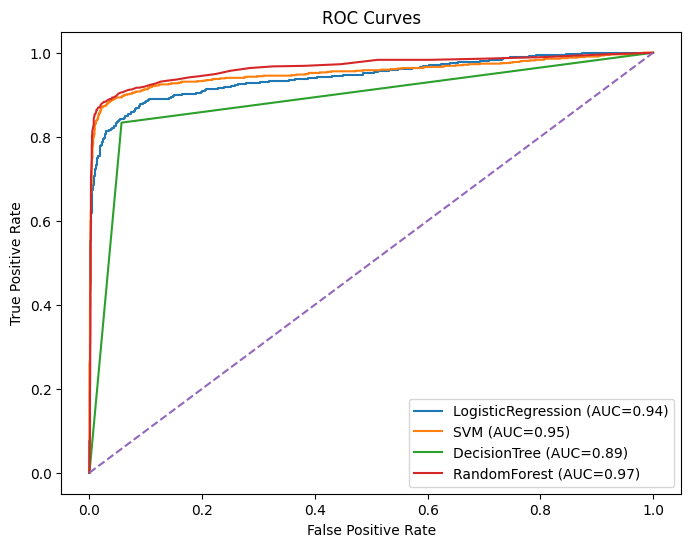

In [6]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:,1]
    else:
        y_prob = pipeline.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.savefig("../reports/figures/roc_curves.png")
plt.show()

In [7]:
import os

os.makedirs("../reports/figures", exist_ok=True)

In [8]:
plt.savefig("../reports/figures/roc_curves.png")

<Figure size 640x480 with 0 Axes>

In [10]:
import os

BASE_REPORT_PATH = "../reports"
FIGURE_PATH = os.path.join(BASE_REPORT_PATH, "figures")

os.makedirs(FIGURE_PATH, exist_ok=True)

In [11]:
plt.savefig(os.path.join(FIGURE_PATH, "roc_curves.png"))

<Figure size 640x480 with 0 Axes>

In [12]:
import os
print(os.getcwd())

c:\Users\saida\OneDrive\Desktop\model-selection-task\notebooks


In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x=results.index, y=results["CV_Accuracy_Std"])
plt.xticks(rotation=45)
plt.title("Cross-Validation Stability (Lower is Better)")
plt.tight_layout()
plt.savefig("../reports/figures/cv_stability.png")
plt.show()

NameError: name 'results' is not defined

<Figure size 800x500 with 0 Axes>

In [14]:
import os

os.makedirs("../reports/figures", exist_ok=True)

In [15]:
import os

os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(8,5))
sns.barplot(x=results.index, y=results["CV_Accuracy_Std"])
plt.xticks(rotation=45)
plt.title("Cross-Validation Stability (Lower is Better)")
plt.tight_layout()
plt.savefig("../reports/figures/cv_stability.png")
plt.show()

NameError: name 'results' is not defined

<Figure size 800x500 with 0 Axes>

In [16]:
import pandas as pd

results = pd.read_csv("../reports/model_comparison.csv", index_col=0)

print(results.head())

FileNotFoundError: [Errno 2] No such file or directory: '../reports/model_comparison.csv'

In [17]:
import os
os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(8,5))
sns.barplot(x=results.index, y=results["CV_Accuracy_Std"])
plt.xticks(rotation=45)
plt.title("Cross-Validation Stability (Lower is Better)")
plt.tight_layout()
plt.savefig("../reports/figures/cv_stability.png")
plt.show()

NameError: name 'results' is not defined

<Figure size 800x500 with 0 Axes>